In [1]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'mathtext.default':  'regular' })
FontSize = 13
plt.rcParams["font.family"] = "serif"

In [2]:
with open("../EWF/marconi.txt", "r") as file:
    marconi_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/marconi.txt", "r") as file:
    marconi_wue= [float(line.strip()) for line in file if line.strip()]
    
with open("../EWF/fugaku.txt", "r") as file:
    fugaku_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/fugaku.txt", "r") as file:
    fugaku_wue= [float(line.strip()) for line in file if line.strip()]
    
with open("../EWF/polaris.txt", "r") as file:
    polaris_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/polaris.txt", "r") as file:
    polaris_wue= [float(line.strip()) for line in file if line.strip()]

with open("../EWF/frontier.txt", "r") as file:
    frontier_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/frontier.txt", "r") as file:
    frontier_wue= [float(line.strip()) for line in file if line.strip()]

In [3]:
import sys 
sys.path.append("..") 
from ThirstyFLOPS.operational import calculate_operational_water
marconi_config = {"wue": np.mean(marconi_wue), "wetbulb": None, "energy":1,"pue": 1.25, "energy_mix": None, "ewf": np.mean(marconi_ewf), "wsi_direct": 1, "wsi_indirect": 1}
fugaku_config = {"wue": np.mean(fugaku_wue), "wetbulb": None, "energy":1,"pue": 1.4, "energy_mix": None, "ewf": np.mean(fugaku_ewf), "wsi_direct": 1, "wsi_indirect": 1}
polaris_config = {"wue": np.mean(polaris_wue), "wetbulb": None, "energy":1,"pue": 1.65, "energy_mix": None, "ewf": np.mean(polaris_ewf), "wsi_direct": 1, "wsi_indirect": 1}
frontier_config = {"wue": np.mean(frontier_wue), "wetbulb": None, "energy":1,"pue": 1.05, "energy_mix": None, "ewf": np.mean(frontier_ewf), "wsi_direct": 1, "wsi_indirect": 1}

off_marconi, on_marconi, _, _ = calculate_operational_water(marconi_config)
off_fugaku, on_fugaku, _, _ = calculate_operational_water(fugaku_config)
off_polaris, on_polaris, _, _ = calculate_operational_water(polaris_config)
off_frontier, on_frontier, _, _ = calculate_operational_water(frontier_config)

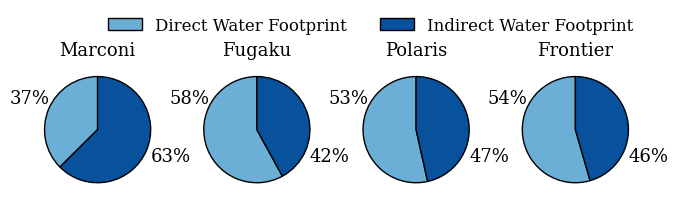

In [4]:
categories = ["Marconi", "Fugaku", "Polaris", "Frontier"]
offsite= [off_marconi, off_fugaku, off_polaris, off_frontier]
onsite = [on_marconi, on_fugaku, on_polaris, on_frontier]
offsite_percent = [100*offsite[0]/(offsite[0]+onsite[0]),100*offsite[1]/(offsite[1]+onsite[1]) ,100*offsite[2]/(offsite[2]+onsite[2]), 100*offsite[3]/(offsite[3]+onsite[3])]
onsite_percent = [100*onsite[0]/(offsite[0]+onsite[0]),100*onsite[1]/(offsite[1]+onsite[1]) ,100*onsite[2]/(offsite[2]+onsite[2]), 100*onsite[3]/(offsite[3]+onsite[3])]

colors = ['#6baed6', '#08519c']

fig, axs = plt.subplots(nrows=1, ncols=4, gridspec_kw={'hspace': 0.4, 'wspace': 0.2, 'bottom': 0.2, 
                    'top': 0.8, 'right':0.995, 'left':0.17}, figsize=(7.4,3),sharey=True)

for i, ax in enumerate(axs.flatten()):
    sizes = [onsite_percent[i], offsite_percent[i]]
    wedges= ax.pie(
        sizes,
        pctdistance=1.3,
        startangle=90,
        colors=colors,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1}
    )
    ax.set_title(categories[i], fontsize=FontSize)
axs[0].text(-1.65,0.5,"37%", fontsize=13,color='black')
axs[0].text(1,-0.6,"63%", fontsize=13,color='black')
axs[1].text(-1.65,0.5,"58%", fontsize=13,color='black')
axs[1].text(1,-0.6,"42%", fontsize=13,color='black')
axs[2].text(-1.65,0.5,"53%", fontsize=13,color='black')
axs[2].text(1,-0.6,"47%", fontsize=13,color='black')
axs[3].text(-1.65,0.5,"54%", fontsize=13,color='black')
axs[3].text(1,-0.6,"46%", fontsize=13,color='black')
fig.legend(loc=(0.15,0.8), frameon = False ,ncol=2,labels=['Direct Water Footprint','Indirect Water Footprint'],fontsize=12)

plt.savefig("../figures/figure7.pdf",bbox_inches='tight')